In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
from collections import defaultdict, Counter

In [5]:
def load_data(filename):
    df = pd.read_csv(filename, header=None)
    df = df.iloc[:, 0:3]
    df.columns = ['node1', 'node2', 'weight']
    return df[['node1', 'node2', 'weight']]

In [6]:
filename = "soc-sign-bitcoinalpha.csv"
df = load_data(filename)

(a)

In [7]:
def get_degree_distributions(edge_list):
    in_deg = defaultdict(int)
    out_deg = defaultdict(int)

    for src, tgt in edge_list:
        out_deg[src] += 1
        in_deg[tgt] += 1

    return in_deg, out_deg

def create_stubs(df):
    in_stubs = []
    out_stubs = []

    for _, row in df.iterrows():
        source = row['node1']
        target = row['node2']
        weight = row['weight'] / 2.0

        out_stubs.append({'node': source, 'weight': weight})
        in_stubs.append({'node': target, 'weight': weight})

    return out_stubs, in_stubs

def pair_stubs(out_stubs, in_stubs):
    random.shuffle(out_stubs)
    random.shuffle(in_stubs)

    edge_list = []

    for out_stub, in_stub in zip(out_stubs, in_stubs):
        edge = (
            out_stub['node'],
            in_stub['node']
        )
        edge_list.append(edge)

    return edge_list

In [8]:
nodes = set(df['node1']) | set(df['node2'])
original_edges = list(zip(df['node1'], df['node2']))
original_in_deg, original_out_deg = get_degree_distributions(original_edges)

In [9]:
all_in_deg_freq = defaultdict(list)
all_out_deg_freq = defaultdict(list)

n_instances = 100

for i in range(n_instances):
    out_stubs, in_stubs = create_stubs(df)
    edge_list = pair_stubs(out_stubs.copy(), in_stubs.copy())
    in_deg, out_deg = get_degree_distributions(edge_list)

    in_freq = Counter(in_deg.values())
    out_freq = Counter(out_deg.values())

    max_k = max(max(in_freq, default=0), max(out_freq, default=0))

    for k in range(1, max_k + 1):
        all_in_deg_freq[k].append(in_freq.get(k, 0))
        all_out_deg_freq[k].append(out_freq.get(k, 0))

In [34]:
def plot_distribution(ks, means, stds, original_freq, title, xlabel, filename):
    total_model = sum(means)
    total_real = sum(original_freq.values())

    all_ks = sorted(set(ks).union(original_freq.keys()))

    model_probs = [means[ks.index(k)] / total_model if k in ks else 0 for k in all_ks]
    model_stds = [stds[ks.index(k)] if k in ks else 0 for k in all_ks]
    real_probs = [original_freq.get(k, 0) / total_real for k in all_ks]

    plt.figure(figsize=(8, 6))

    plt.plot(all_ks, model_probs, '-', marker='o', color='tab:blue', label='Configuration model (mean)')
    plt.errorbar(all_ks, model_probs, yerr=model_stds, fmt='none', capsize=4, ecolor='tab:blue', alpha=0.5)

    plt.plot(all_ks, real_probs, 'r--', label='Real-world network', linewidth=2)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(xlabel)
    plt.ylabel("Probability P(k)")
    plt.title(title)
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.legend()
    plt.tight_layout()
    plt.savefig(filename)

In [23]:
ks_in = sorted(all_in_deg_freq.keys())
means_in = [np.mean(all_in_deg_freq[k]) for k in ks_in]
stds_in = [np.std(all_in_deg_freq[k]) for k in ks_in]

ks_out = sorted(all_out_deg_freq.keys())
means_out = [np.mean(all_out_deg_freq[k]) for k in ks_out]
stds_out = [np.std(all_out_deg_freq[k]) for k in ks_out]

original_in_freq = Counter(original_in_deg.values())
original_out_freq = Counter(original_out_deg.values())

original_ks_in = list(original_in_freq.keys())
original_vals_in = list(original_in_freq.values())

original_ks_out = list(original_out_freq.keys())
original_vals_out = list(original_out_freq.values())

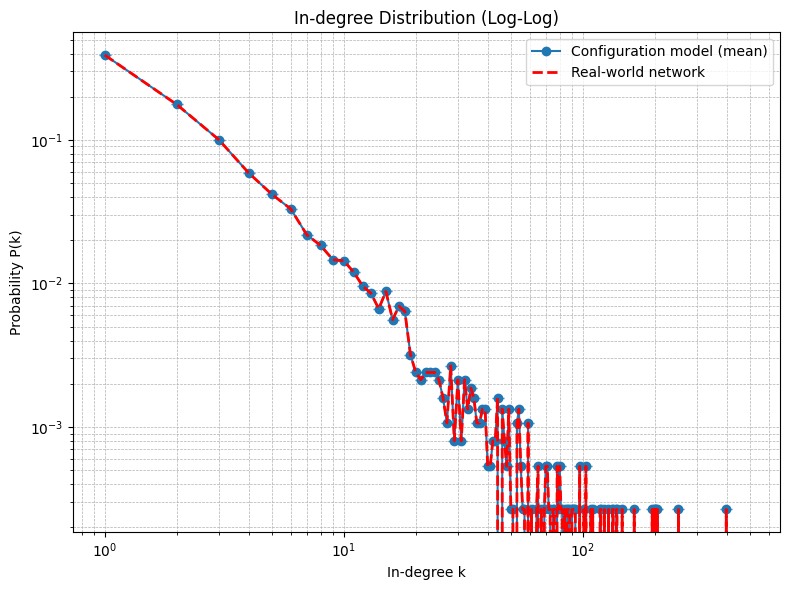

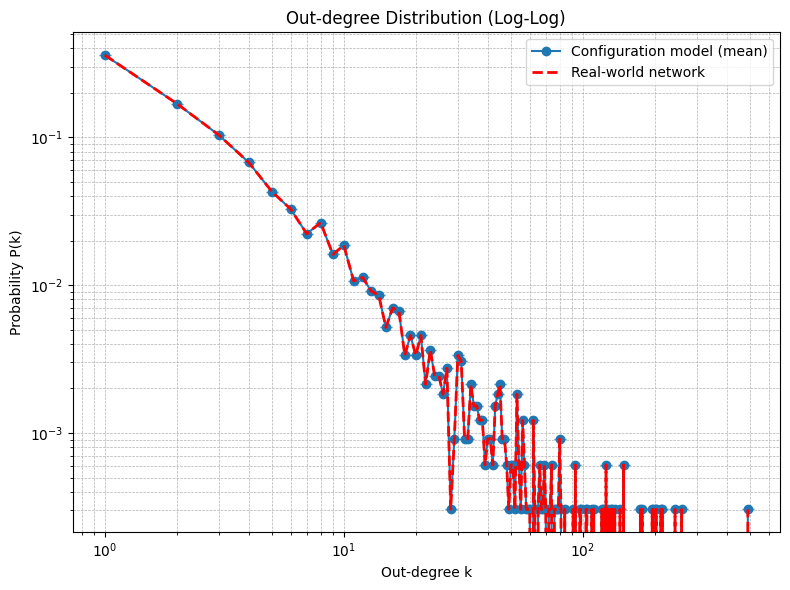

In [35]:
plot_distribution(ks_in, means_in, stds_in, original_in_freq, "In-degree Distribution (Log-Log)", "In-degree k", "configuration_model_in_degree_distribution.png")
plot_distribution(ks_out, means_out, stds_out, original_out_freq, "Out-degree Distribution (Log-Log)", "Out-degree k", "configuration_model_out_degree_distribution.png")

The degree distribution of real-world network and averaged random graph over 100 instances generated through configuration model follows the same distribution since the random graph generated through configuration model preserves the degree sequence of real-world network and, self loops and multiple edges between a pair of nodes is not allowed.

(b)

In [13]:
def build_adj_list(df):
    out_adj = defaultdict(set)
    in_adj = defaultdict(set)
    weights = dict()

    for _, row in df.iterrows():
        u, v, w = row['node1'], row['node2'], row['weight']
        out_adj[u].add(v)
        in_adj[v].add(u)
        weights[(u, v)] = w

    return out_adj, in_adj, weights

In [14]:
nodes = set(df['node1']).union(set(df['node2']))
out_adj, in_adj, weights = build_adj_list(df)

In [15]:
def get_degrees(out_adj, in_adj, nodes):
    in_deg = {n: len(in_adj[n]) for n in nodes}
    out_deg = {n: len(out_adj[n]) for n in nodes}
    return in_deg, out_deg

def swap_edges(out_adj, in_adj, weights, num_swaps):
    edge_list = list(weights.keys())
    nodes = set(out_adj.keys()).union(in_adj.keys())

    successful_swaps = 0
    attempts = 0
    max_attempts = 3 * num_swaps

    while successful_swaps < num_swaps and attempts < max_attempts:
        attempts += 1
        (a, b) = random.choice(edge_list)
        (c, d) = random.choice(edge_list)

        if len({a, b, c, d}) < 4:
            continue
        if (a, d) in weights or (c, b) in weights:
            continue

        w1 = weights[(a, b)]
        w2 = weights[(c, d)]
        new_weight = (w1 + w2) / 2

        # Remove old edges
        del weights[(a, b)]
        del weights[(c, d)]
        out_adj[a].remove(b)
        in_adj[b].remove(a)
        out_adj[c].remove(d)
        in_adj[d].remove(c)

        # Add new edges
        weights[(a, d)] = new_weight
        weights[(c, b)] = new_weight
        out_adj[a].add(d)
        in_adj[d].add(a)
        out_adj[c].add(b)
        in_adj[b].add(c)

        edge_list.remove((a, b))
        edge_list.remove((c, d))
        edge_list.append((a, d))
        edge_list.append((c, b))

        successful_swaps += 1

    return out_adj, in_adj, weights

def compute_degree_distribution(degree_dict):
    freq = Counter(degree_dict.values())
    return freq

In [16]:
real_in_deg, real_out_deg = get_degrees(out_adj, in_adj, nodes)
real_in_hist = compute_degree_distribution(real_in_deg)
real_out_hist = compute_degree_distribution(real_out_deg)
max_k = max(max(real_in_deg.values()), max(real_out_deg.values()))

In [17]:
in_distributions = []
out_distributions = []
num_swaps = len(original_edges)

n_instances = 100

for _ in range(n_instances):
    out_copy = {k: set(v) for k, v in out_adj.items()}
    in_copy = {k: set(v) for k, v in in_adj.items()}
    weight_copy = dict(weights)

    new_out, new_in, _ = swap_edges(out_copy, in_copy, weight_copy, num_swaps)
    in_deg, out_deg = get_degrees(new_out, new_in, nodes)

    in_distributions.append(compute_degree_distribution(in_deg))
    out_distributions.append(compute_degree_distribution(out_deg))

In [18]:
def aggregate_distributions(freq_list, max_k, total_nodes):
    means = []
    stds = []
    for k in range(1, max_k + 1):
        values = [f.get(k, 0) / total_nodes for f in freq_list]
        means.append(np.mean(values))
        stds.append(np.std(values))
    return means, stds

In [19]:
ks = list(range(1, max_k + 1))
total_nodes = len(nodes)

in_means, in_stds = aggregate_distributions(in_distributions, max_k, total_nodes)
out_means, out_stds = aggregate_distributions(out_distributions, max_k, total_nodes)

In [26]:
def plot_distribution(ks, means, stds, real_dist, degree_type, filename, total_nodes):
    plt.figure(figsize=(8, 5))

    plt.plot(ks, means, '-', marker='o', color='tab:blue', label=f'{degree_type.capitalize()}-degree (swapped mean)')
    plt.errorbar(ks, means, yerr=stds, fmt='none', capsize=4, ecolor='tab:blue', alpha=0.5)

    real_vals = [real_dist.get(k, 0) / total_nodes for k in ks]
    plt.plot(ks, real_vals, 'r--', label=f'{degree_type.capitalize()}-degree (real)', linewidth=2)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel(f'{degree_type.capitalize()}-Degree (k)')
    plt.ylabel('Probability (P(k))')
    plt.title(f'{degree_type.capitalize()}-Degree Distribution (Log-Log)')
    plt.legend()
    plt.grid(True, which='both', ls='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(filename)

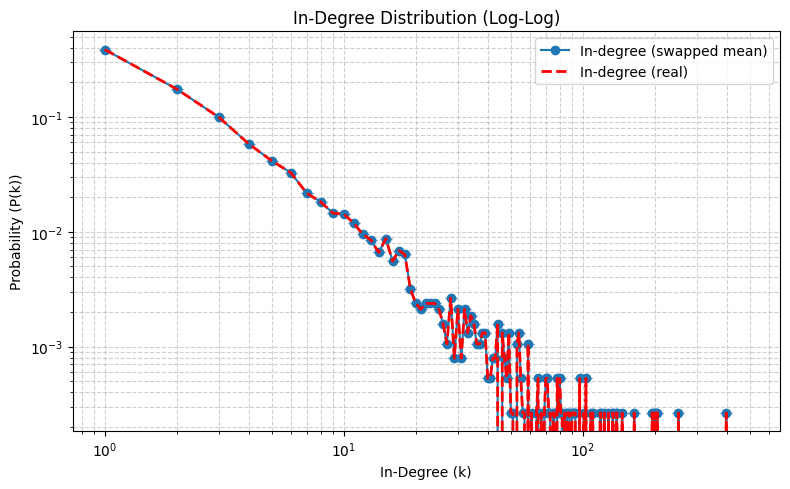

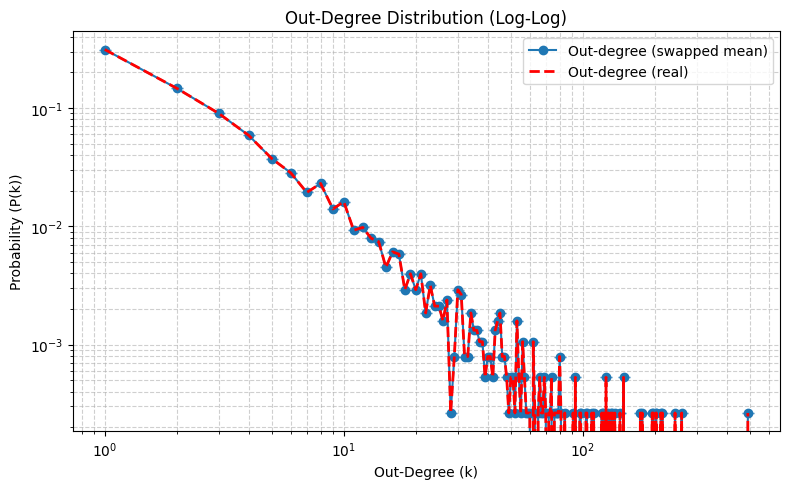

In [27]:
plot_distribution(ks, in_means, in_stds, real_in_hist, 'in', 'edge_swapping_in_degree_distribution.png', total_nodes)
plot_distribution(ks, out_means, out_stds, real_out_hist, 'out', 'edge_swapping_out_degree_distribution.png', total_nodes)

The degree distribution of real-world network and averaged random graph over 100 instances generated through edge swapping strategy follows the same distribution since the random graph generated through edge swapping preserves the degree sequence of real-world network and, self loops and multiple edges between a pair of nodes is not allowed.